# 🐱 Cats vs Dogs Image Classification using Transfer Learning

## Project Overview

This project builds a binary image classifier capable of distinguishing between cats and dogs using **Transfer Learning** with **MobileNetV2**, a lightweight convolutional neural network pretrained on the ImageNet dataset.

Instead of training a deep neural network from scratch, the project leverages the rich visual features learned by MobileNetV2 and adapts them to the Cats vs Dogs classification task. This approach significantly reduces training time while achieving high classification performance.

The project follows a complete deep learning workflow, including data loading, preprocessing, model development, transfer learning, fine-tuning, evaluation, and inference. The codebase is organized into reusable Python modules to improve readability, maintainability, and scalability.

---

## Dataset

The model is trained on the **Cats vs Dogs** dataset from Kaggle.

- **Classes:** Cat, Dog
- **Training images:** 2,000
- **Validation images:** 1,000
- **Image size:** 160 × 160 pixels

---

## Model Architecture

The classifier is built using **MobileNetV2** as the feature extractor.

The training process consists of two stages:

1. **Transfer Learning**
   - Freeze all layers of the pretrained MobileNetV2 model.
   - Train only the custom classification head.

2. **Fine-Tuning**
   - Unfreeze the last layers of MobileNetV2.
   - Continue training with a smaller learning rate to improve performance.

---

## Technologies Used

- Python
- TensorFlow / Keras
- NumPy
- Matplotlib
- Scikit-learn
- Jupyter Notebook

---

## Project Structure

The project is organized into modular components:

- **dataset.py** – Dataset loading and preprocessing
- **model.py** – Model architecture
- **train.py** – Training and fine-tuning pipeline
- **predict.py** – Single-image prediction
- **evaluate.py** – Model evaluation and visualization

---

## Features Demonstrated

- Transfer Learning
- Fine-Tuning
- Data Augmentation
- TensorFlow Dataset API
- Early Stopping
- Model Checkpointing
- Model Evaluation
- Confusion Matrix
- Classification Report
- Single Image Prediction

---

## Objective

The goal of this project is to demonstrate best practices for developing an image classification system using transfer learning while maintaining clean, modular, and reusable code suitable for a production-style machine learning project and a professional GitHub portfolio.

# 1. Loading and Exploring the Dataset

In [4]:
import sys
sys.path.append("..")
from src.dataset import load_dataset

train_dataset, validation_dataset, class_names=load_dataset()

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [5]:
print(f"Training batches: {len(train_dataset)}")
print(f"Validation batches: {len(validation_dataset)}")

print(f"Class names: {class_names}")

Training batches: 63
Validation batches: 32
Class names: ['cats', 'dogs']


## Visualizing Sample Images

The following images are randomly sampled from the training dataset. Visual inspection helps verify that the images have been loaded correctly and that the labels correspond to the correct classes.

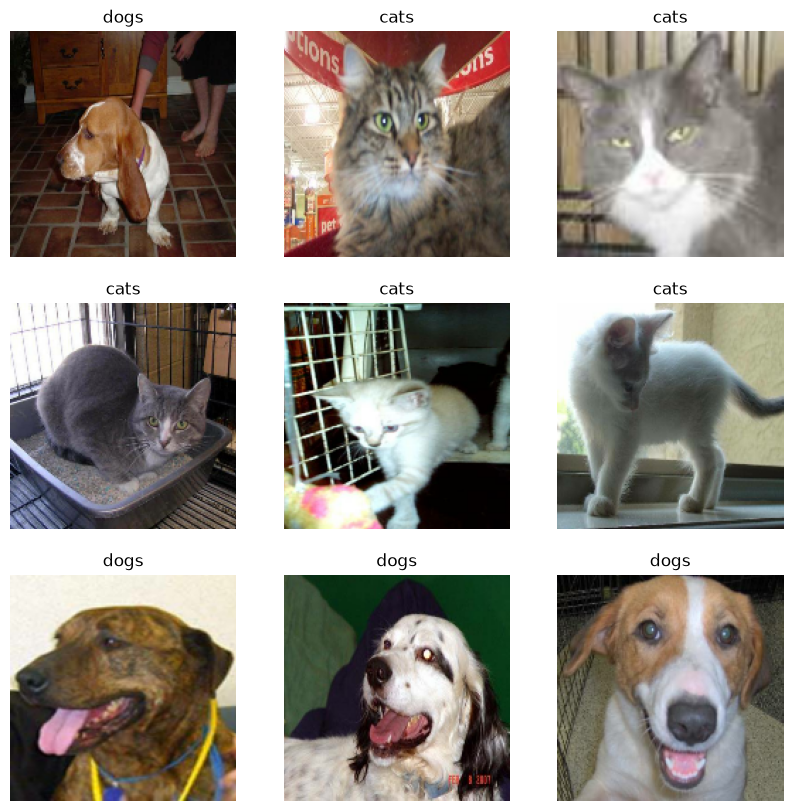

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## 2. Building the model


In [7]:
from src.model import create_model

head_model=create_model()
head_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 3. Training the Classification Head



In [16]:
from src.train import train_head_model

head_model,head_history= train_head_model()

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8270 - loss: 0.3727
Epoch 1: val_loss improved from None to 0.10810, saving model to ../models/head_training.keras

Epoch 1: finished saving model to ../models/head_training.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 293ms/step - accuracy: 0.8270 - loss: 0.3727 - val_accuracy: 0.9770 - val_loss: 0.1081
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9360 - loss: 0.1761
Epoch 2: val_loss improved from 0.10810 to 0.07866, saving model to ../models/head_training.keras

Epoch 2: finished saving model to ../models/head_training.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 282ms/step - accuracy: 0.9360 - loss: 0.1761 - val_accuracy: 0.9790 - val_loss: 0.0787
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9320 - loss: 0.1554
Epoch 3: val_loss improved from 0.07866 to 0.06803, saving model to ../models/head_training.keras

Epoch

## 4. Plotting the first history



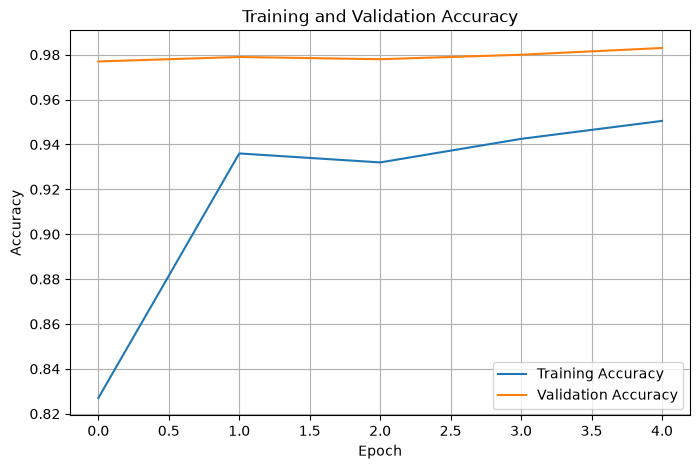

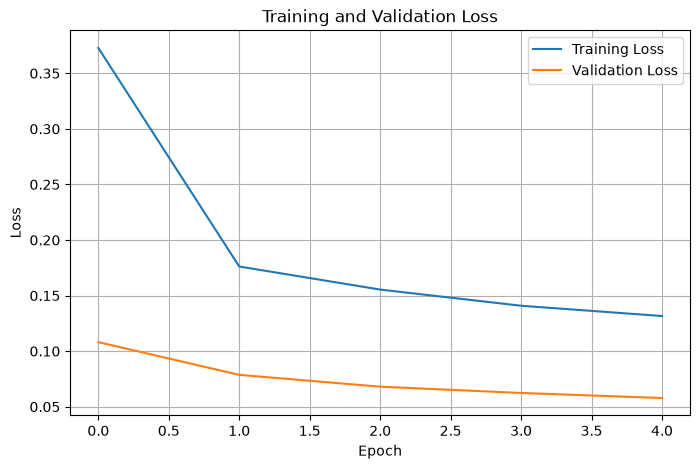

In [17]:
from src.evaluate import plot_history

plot_history(head_history)

## 5. Fine tuning the model


In [18]:
from src.train import fine_tune_model
initial_epoch=head_history.epoch[-1]
final_model,final_history=fine_tune_model(initial_epoch=initial_epoch)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9045 - loss: 0.2313
Epoch 5: val_loss improved from None to 0.05681, saving model to ../models/final_training.keras

Epoch 5: finished saving model to ../models/final_training.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 351ms/step - accuracy: 0.9045 - loss: 0.2313 - val_accuracy: 0.9800 - val_loss: 0.0568
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9475 - loss: 0.1396
Epoch 6: val_loss improved from 0.05681 to 0.04364, saving model to ../models/final_training.keras

Epoch 6: finished saving model to ../models/final_training.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 340ms/step - accuracy: 0.9475 - loss: 0.1396 - val_accuracy: 0.9840 - val_loss: 0.0436
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.9515 - loss: 0.1160
Epoch 7: val_loss improved from 0.04364 to 0.03742, saving model to ../models/final_training.kera

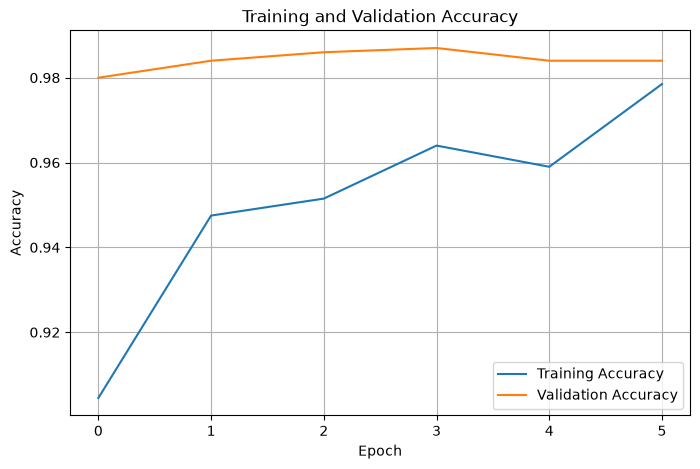

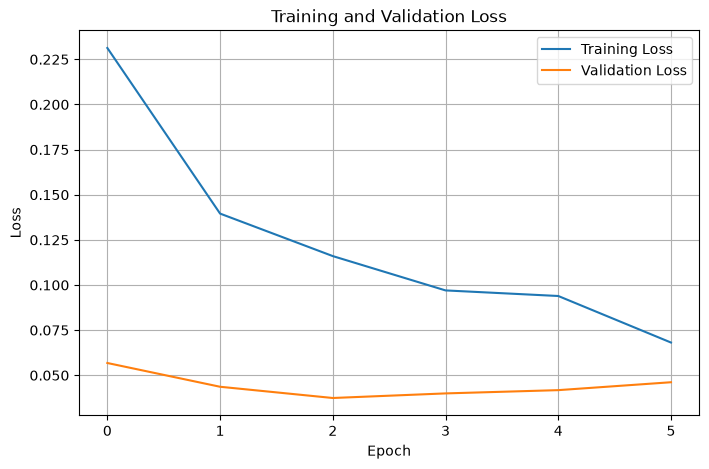

In [19]:
plot_history(final_history)

## 6. Model evaluation


32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 162ms/step - accuracy: 0.9860 - loss: 0.0374
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 929ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

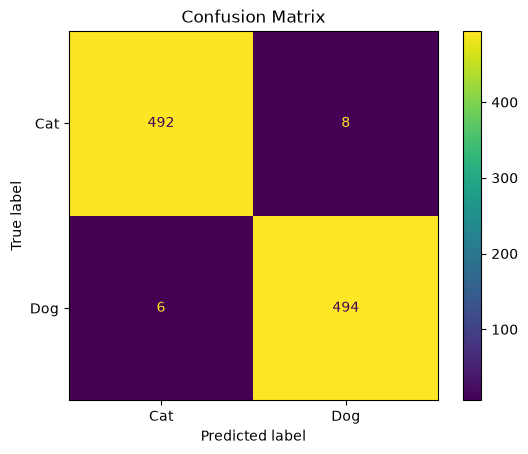

In [20]:
from src.evaluate import evaluate_model, plot_confusion_matrix
final_model_path="../models/final_training.keras"
loss, accuracy = evaluate_model(final_model_path, validation_dataset)
plot_confusion_matrix(final_model_path,validation_dataset )

In [23]:
import importlib
import src.predictions

importlib.reload(src.predictions)

<module 'src.predictions' from 'e:\\ML-Projects\\Cats-vs-Dogs\\notebooks\\..\\src\\predictions.py'>

## 7. Testing on new images


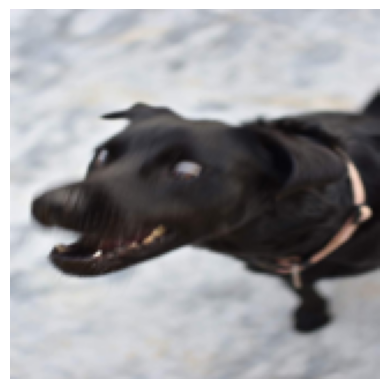

{'label': 'Dog', 'confidence': 0.9999923706054688, 'probability': 0.9999923706054688}


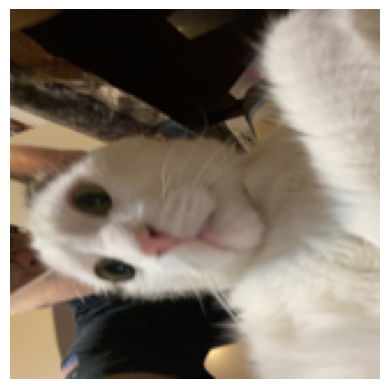

{'label': 'Cat', 'confidence': 0.9288941025733948, 'probability': 0.07110591232776642}


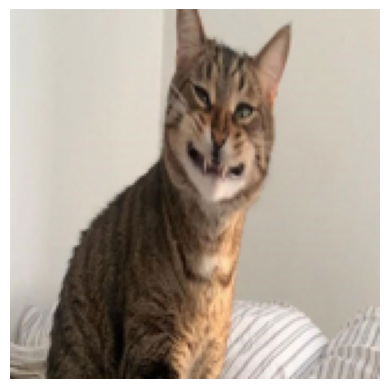

{'label': 'Cat', 'confidence': 0.99908846616745, 'probability': 0.0009115586872212589}


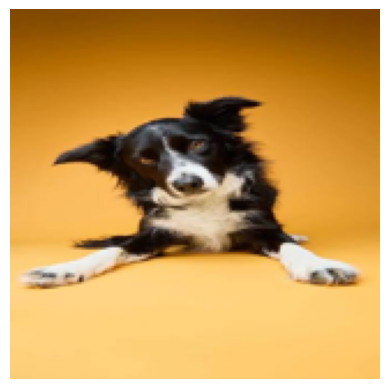

{'label': 'Dog', 'confidence': 0.9970280528068542, 'probability': 0.9970280528068542}


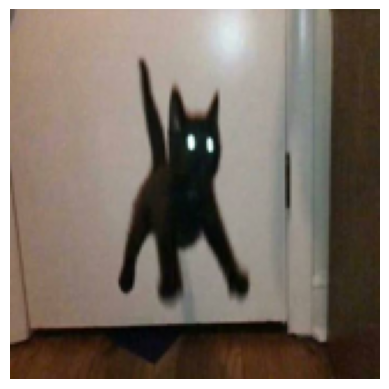

{'label': 'Cat', 'confidence': 0.9888063073158264, 'probability': 0.011193701066076756}


In [24]:
from src.predictions import predict_image

test_images=[
    "../testing_images/test_img1.jpg",
    "../testing_images/test_img2.jpg",
    "../testing_images/test_img3.jpg",
    "../testing_images/test_img4.jpg",
    "../testing_images/test_img5.jpg",
]

for img_path in test_images:
    result=predict_image(model_path=final_model_path, img_path=img_path)
    print(result)
    

## Project Conclusion

- **Summary:** Built a binary image classifier for cats vs dogs using MobileNetV2 transfer learning with a two-stage training process (head training + fine-tuning).
- **Results:** Model artifacts are saved under `models/` (e.g. `final_training.keras`). Evaluation and the confusion matrix cells show validation loss and accuracy — refer to the evaluation outputs for exact metrics.
- **Key Takeaways:** Transfer learning significantly reduced training time while providing strong baseline performance; data augmentation and careful fine-tuning improved generalization slightly.
- **Artifacts:** `src/` modules (dataset.py, model.py, train.py, evaluate.py, predictions.py), `models/head_training.keras`, `models/final_training.keras`, and this notebook for reproduction.
- **Next Steps:** collect more labeled images, experiment with larger architectures or ensembling, convert the final model for mobile/edge deployment (TensorFlow Lite), and add an inference endpoint for real-time predictions.
- **Reproduce:** Run the notebook cells in order: load dataset → build model → train head → fine-tune → evaluate → test predictions.
